# **Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

# **Data Collecting**

In [2]:
df = pd.read_csv('data/synthetic_data.csv')
df = df.set_index("timestamp_prediction")
df = df.sort_index()

In [3]:
df.head(10)

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2026-01-01 06:00:00,Cakung,1,Tps 3R,93497,8456,3,0,0,2.37,0.00,0.0,9.61,15.30
2026-01-01 06:00:00,Kepulauan Seribu Selatan,121,Tipe 4,98929,6839,3,0,0,2.20,0.00,0.0,14.68,33.29
2026-01-01 06:00:00,Jagakarsa,44,Tipe 4,91076,8740,3,0,0,1.69,0.00,0.0,19.78,35.19
2026-01-01 06:00:00,Jatinegara,45,Tipe 1,84340,1133,3,0,0,1.06,7.85,0.0,15.04,25.12
2026-01-01 06:00:00,Makasar,84,Tipe 4,89630,6024,3,0,0,0.78,16.40,0.0,8.91,24.54
2026-01-01 06:00:00,Menteng,93,Tipe 2,109721,2607,3,0,0,2.15,0.00,0.0,14.19,28.68
2026-01-01 06:00:00,Jatinegara,46,Tipe 2,56097,1937,3,0,0,1.73,0.00,0.0,6.92,14.51
2026-01-01 06:00:00,Tebet,148,Tipe 1,102908,2655,3,0,0,2.82,0.00,0.0,13.23,24.93
2026-01-01 06:00:00,Kepulauan Seribu Selatan,119,Tps 3R,105899,7218,3,0,0,0.56,0.00,0.0,7.13,24.62


# **Exploratory Data Analysis**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54750 entries, 2026-01-01 06:00:00 to 2026-12-31 06:00:00
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   kecamatan                54750 non-null  object 
 1   tps_id                   54750 non-null  int64  
 2   tps_type                 54750 non-null  object 
 3   zone_population          54750 non-null  int64  
 4   tps_capacity_kg          54750 non-null  int64  
 5   day_of_week              54750 non-null  int64  
 6   is_weekend               54750 non-null  int64  
 7   is_holiday               54750 non-null  int64  
 8   daily_growth_rate        54750 non-null  float64
 9   rainfall_today           54750 non-null  float64
 10  event_urgency_score      54750 non-null  float64
 11  current_fill_percentage  54750 non-null  float64
 12  target_fill_percentage   54750 non-null  float64
dtypes: float64(5), int64(6), object(2)
memory usage: 

In [5]:
df.duplicated().sum()

0

In [6]:
df.isna().sum()

kecamatan                  0
tps_id                     0
tps_type                   0
zone_population            0
tps_capacity_kg            0
day_of_week                0
is_weekend                 0
is_holiday                 0
daily_growth_rate          0
rainfall_today             0
event_urgency_score        0
current_fill_percentage    0
target_fill_percentage     0
dtype: int64

In [7]:
df.nunique()

kecamatan                    44
tps_id                      150
tps_type                      5
zone_population             150
tps_capacity_kg             150
day_of_week                   7
is_weekend                    2
is_holiday                    2
daily_growth_rate           251
rainfall_today             3323
event_urgency_score          32
current_fill_percentage    5669
target_fill_percentage     8404
dtype: int64

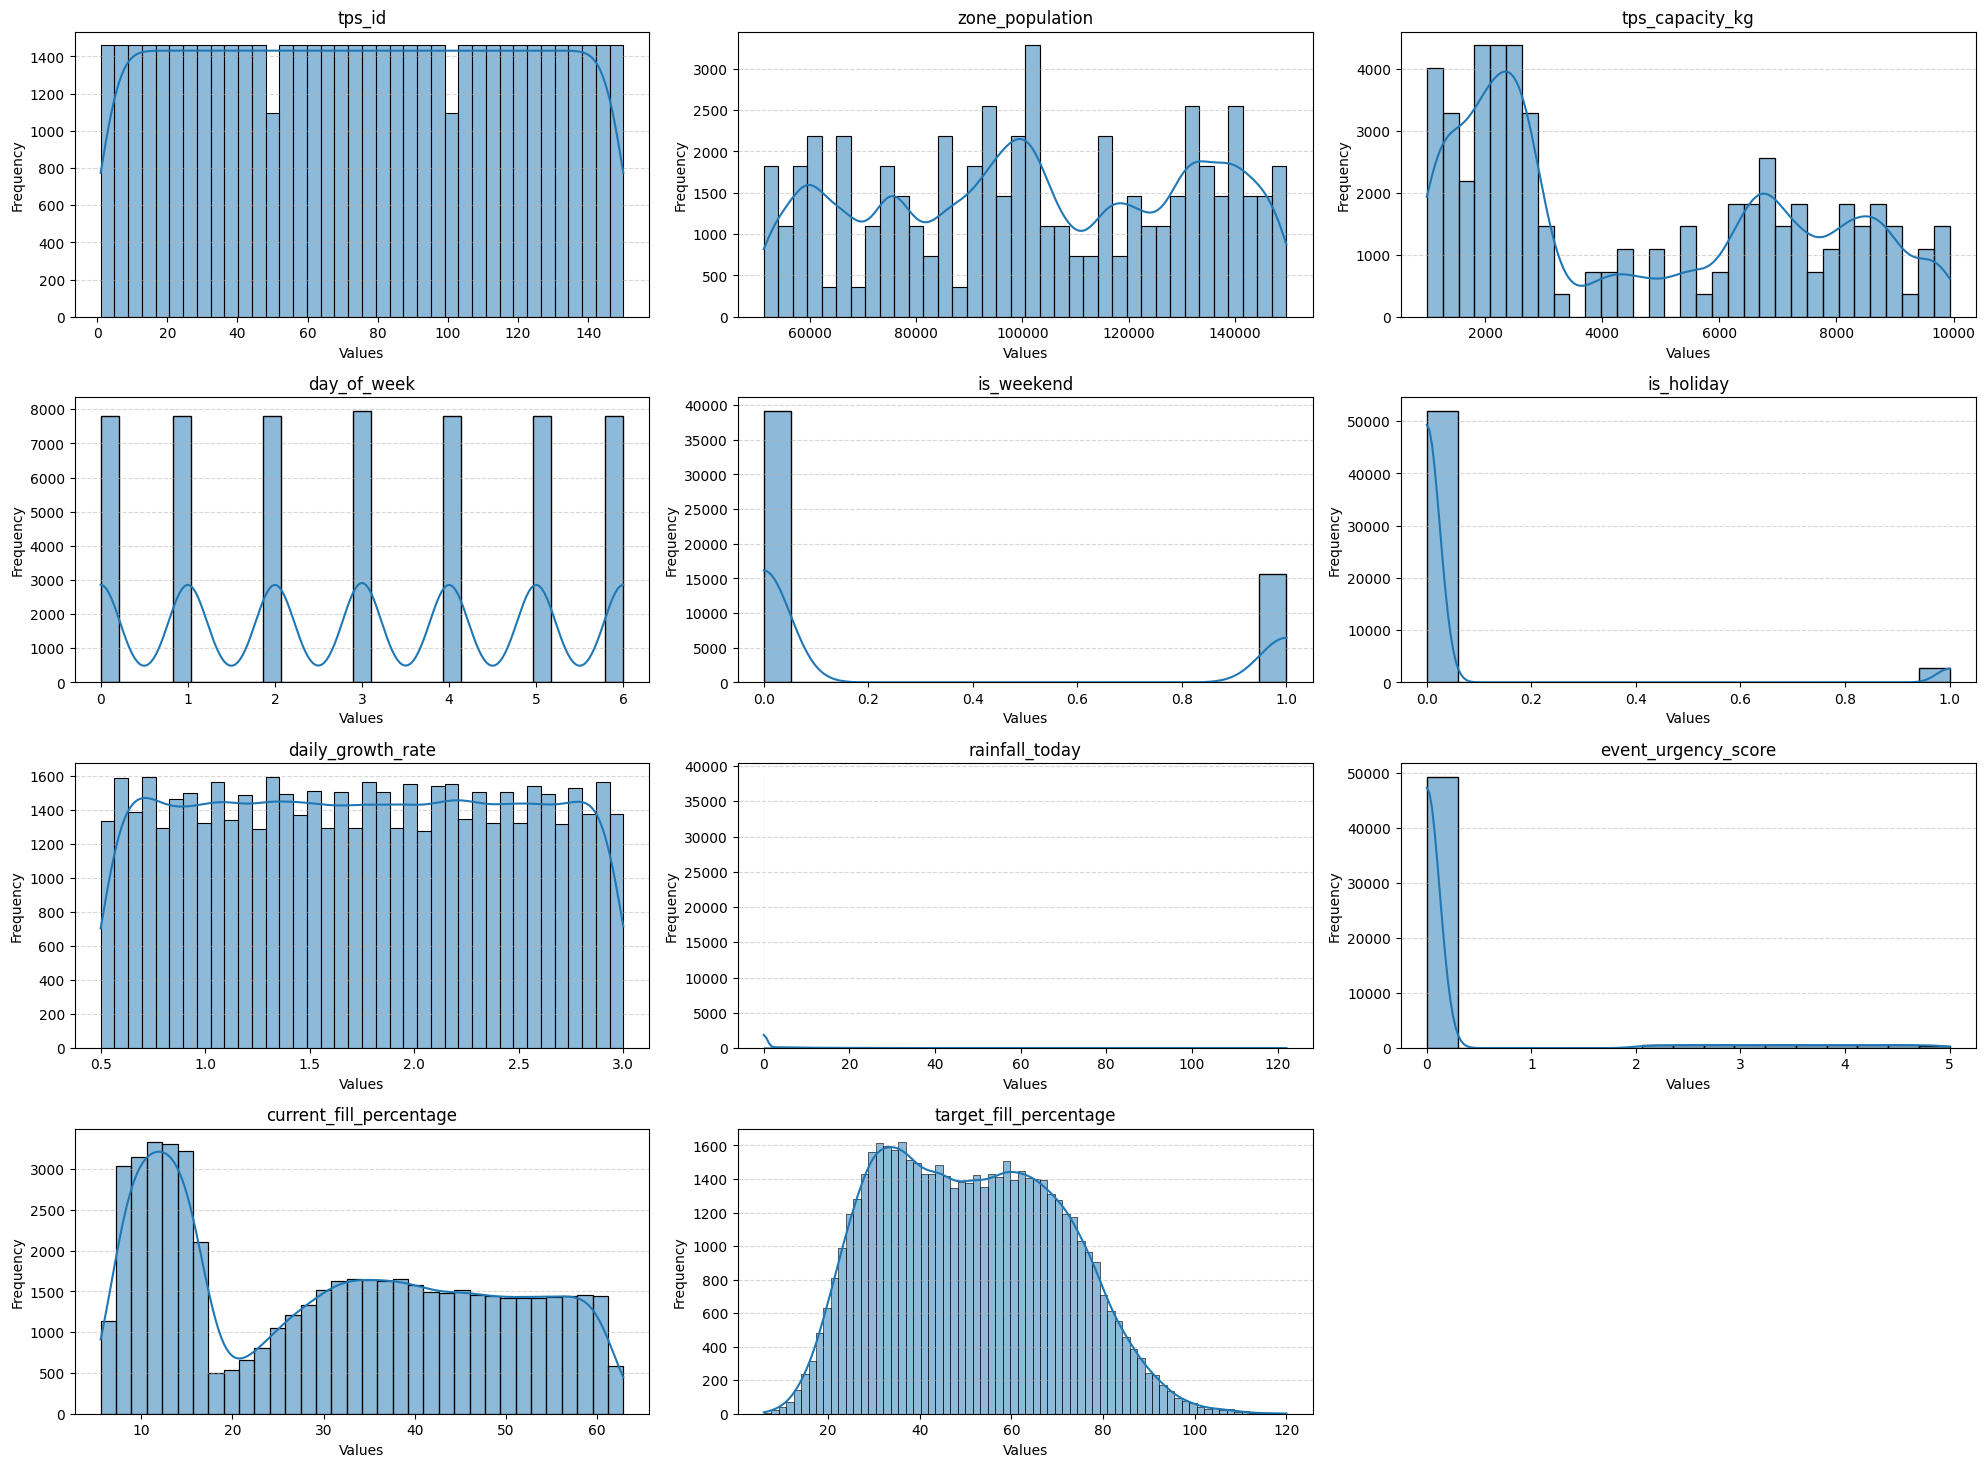

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], ax=ax[i], kde=True)
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")
    ax[i].grid(axis='y', alpha=0.5, linestyle='--')


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

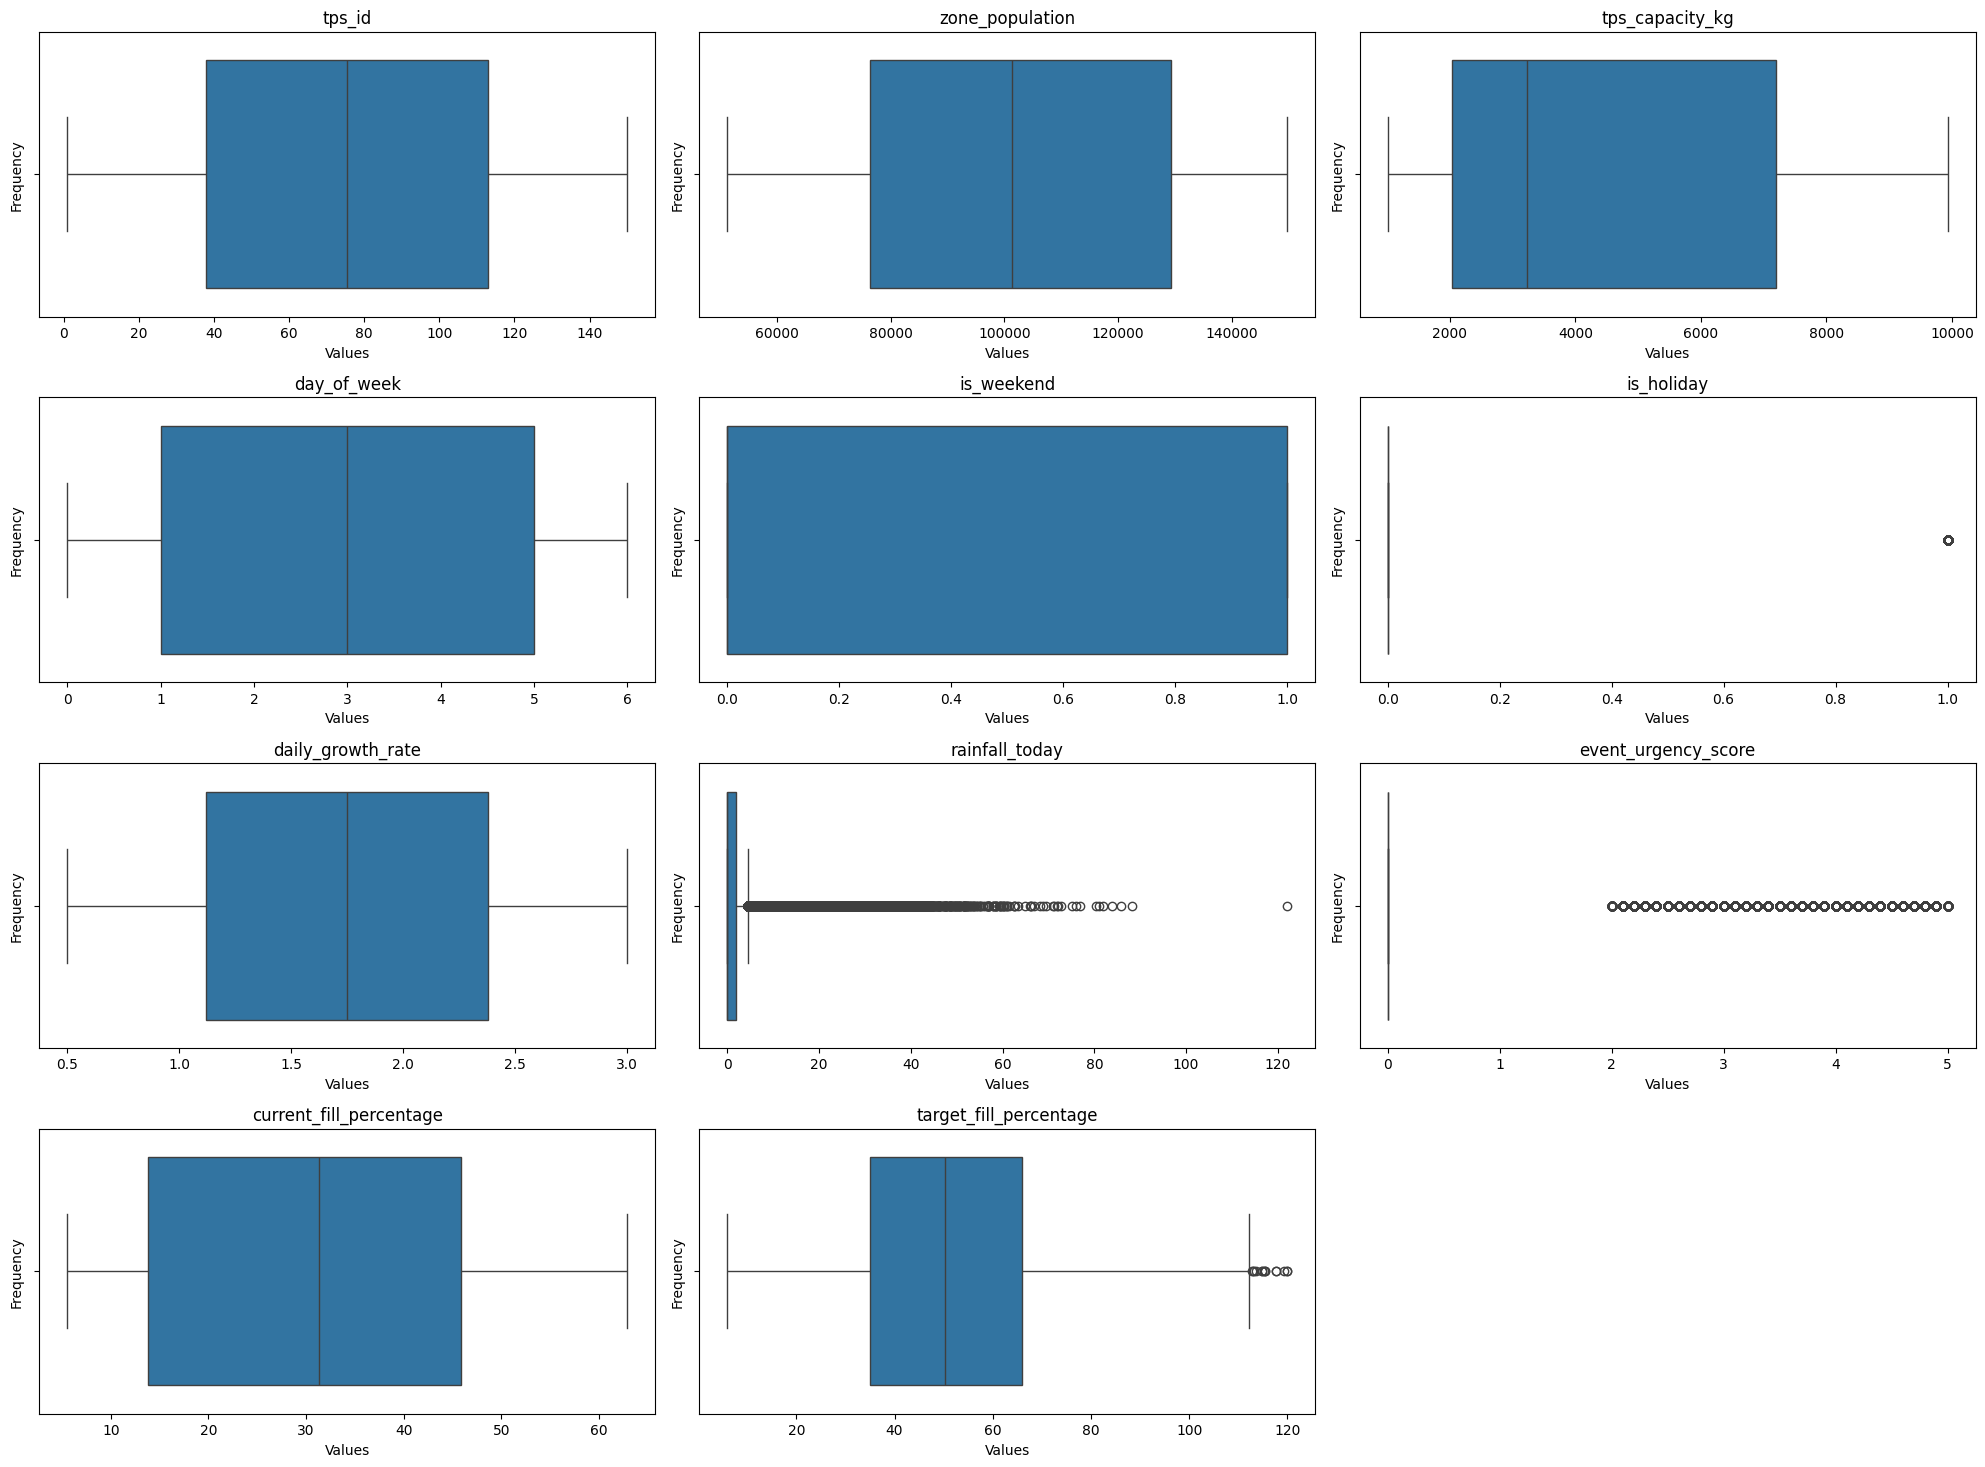

In [9]:
fig, ax = plt.subplots(5, 3, figsize=(20,18))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(df[col], ax=ax[i], orient="h")
    ax[i].set_title(col)
    ax[i].set_xlabel("Values")
    ax[i].set_ylabel("Frequency")


for j in range(len(num_cols), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

In [10]:
print(df["kecamatan"].unique())

['Cakung' 'Kepulauan Seribu Selatan' 'Jagakarsa' 'Jatinegara' 'Makasar'
 'Menteng' 'Tebet' 'Pesanggrahan' 'Johar Baru' 'Kalideres' 'Cengkareng'
 'Tanjung Priok' 'Kepulauan Seribu Utara' 'Duren Sawit' 'Gambir'
 'Sawah Besar' 'Cempaka Putih' 'Mampang Prapatan' 'Pulogadung'
 'Grogol Petamburan' 'Cilandak' 'Senen' 'Penjaringan' 'Kemayoran'
 'Pasar Minggu' 'Kembangan' 'Pancoran' 'Koja' 'Palmerah' 'Kramat Jati'
 'Pademangan' 'Kebayoran Baru' 'Kebayoran Lama' 'Kebon Jeruk' 'Pasar Rebo'
 'Kelapa Gading' 'Cipayung' 'Tanah Abang' 'Cilincing' 'Tambora' 'Ciracas'
 'Setiabudi' 'Matraman' 'Taman Sari']


In [11]:
for i in df["tps_id"].unique():
    tps_id = i

    capacity = df.groupby("tps_id")["tps_capacity_kg"]

In [14]:
df.groupby("tps_id")["tps_capacity_kg"].first().to_dict()

{1: 8456,
 2: 2342,
 3: 1549,
 4: 4476,
 5: 9556,
 6: 8989,
 7: 2749,
 8: 6228,
 9: 8095,
 10: 2341,
 11: 6590,
 12: 2972,
 13: 1165,
 14: 7998,
 15: 7909,
 16: 1113,
 17: 2519,
 18: 8145,
 19: 1155,
 20: 1081,
 21: 4979,
 22: 6272,
 23: 6300,
 24: 1817,
 25: 2776,
 26: 3841,
 27: 6993,
 28: 8689,
 29: 2501,
 30: 2147,
 31: 7487,
 32: 7316,
 33: 1119,
 34: 2017,
 35: 3800,
 36: 8200,
 37: 2224,
 38: 4214,
 39: 9587,
 40: 9930,
 41: 1204,
 42: 2320,
 43: 4010,
 44: 8740,
 45: 1133,
 46: 1937,
 47: 3124,
 48: 9734,
 49: 2428,
 50: 7373,
 51: 6528,
 52: 2665,
 53: 2322,
 54: 8401,
 55: 2098,
 56: 2199,
 57: 4829,
 58: 6871,
 59: 2158,
 60: 2768,
 61: 9504,
 62: 1889,
 63: 8235,
 64: 1653,
 65: 2960,
 66: 9673,
 67: 1631,
 68: 1863,
 69: 8582,
 70: 7408,
 71: 2629,
 72: 1396,
 73: 5584,
 74: 8953,
 75: 1007,
 76: 6678,
 77: 6667,
 78: 2248,
 79: 2338,
 80: 7202,
 81: 1712,
 82: 1471,
 83: 4910,
 84: 6024,
 85: 1321,
 86: 2523,
 87: 4319,
 88: 8141,
 89: 2573,
 90: 2867,
 91: 8859,
 92: 254

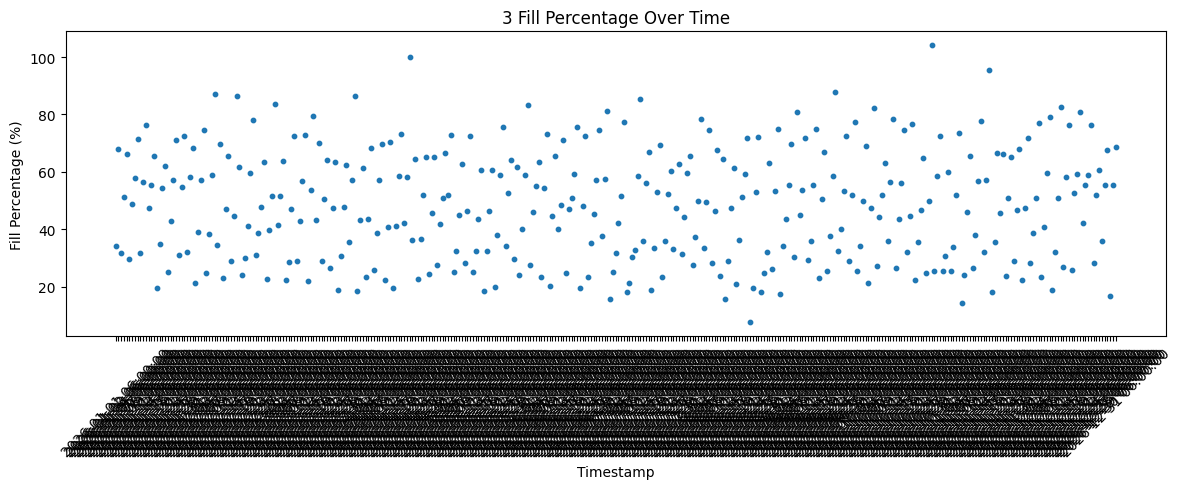

In [11]:
subset = df[df["tps_id"] == 3]

plt.figure(figsize=(12, 5))

plt.scatter(
    subset.index,
    subset["target_fill_percentage"],
    s=10  # dot size
)

plt.xlabel("Timestamp")
plt.ylabel("Fill Percentage (%)")
plt.title(f"{subset['tps_id'].iloc[0]} Fill Percentage Over Time")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [12]:
preproc_df = df.copy()
preproc_df.head()

,kecamatan,tps_id,tps_type,zone_population,tps_capacity_kg,day_of_week,is_weekend,is_holiday,daily_growth_rate,rainfall_today,event_urgency_score,current_fill_percentage,target_fill_percentage
timestamp_prediction,,,,,,,,,,,,,
2026-01-01 06:00:00,Cakung,1,Tps 3R,93497,8456,3,0,0,2.37,0.00,0.0,9.61,15.30
2026-01-01 06:00:00,Kepulauan Seribu Selatan,121,Tipe 4,98929,6839,3,0,0,2.20,0.00,0.0,14.68,33.29
2026-01-01 06:00:00,Jagakarsa,44,Tipe 4,91076,8740,3,0,0,1.69,0.00,0.0,19.78,35.19
2026-01-01 06:00:00,Jatinegara,45,Tipe 1,84340,1133,3,0,0,1.06,7.85,0.0,15.04,25.12
2026-01-01 06:00:00,Makasar,84,Tipe 4,89630,6024,3,0,0,0.78,16.40,0.0,8.91,24.54


## **Train Test Split**

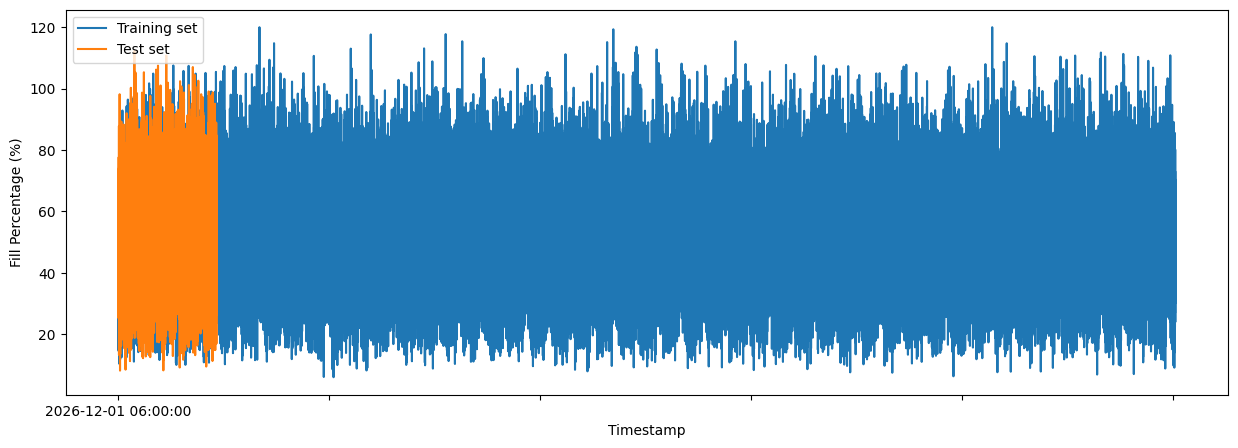

In [13]:
train = preproc_df.loc[preproc_df.index <= "2026-11-30 06:00:00"]
test = preproc_df.loc[preproc_df.index > "2026-11-30 06:00:00"]

fig, ax = plt.subplots(figsize=(15,5))
train["target_fill_percentage"].plot(ax=ax, label="Training set")
test["target_fill_percentage"].plot(ax=ax, label="Test set")

ax.set_xlabel("Timestamp")
ax.set_ylabel("Fill Percentage (%)")
ax.legend()

plt.show()

## **Label Encoding**

In [14]:
encoding_cols = [
    "kecamatan",
    "tps_type"
]

encoders = {}

for col in encoding_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le

C:\Users\Xavier\AppData\Local\Temp\ipykernel_5384\4125509108.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[col] = le.fit_transform(train[col])
C:\Users\Xavier\AppData\Local\Temp\ipykernel_5384\4125509108.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[col] = le.fit_transform(train[col])


In [15]:
train.dtypes

kecamatan                    int32
tps_id                       int64
tps_type                     int32
zone_population              int64
tps_capacity_kg              int64
day_of_week                  int64
is_weekend                   int64
is_holiday                   int64
daily_growth_rate          float64
rainfall_today             float64
event_urgency_score        float64
current_fill_percentage    float64
target_fill_percentage     float64
dtype: object

In [16]:
for col in encoding_cols:
    le = encoders[col]
    test[col] = le.transform(test[col])

C:\Users\Xavier\AppData\Local\Temp\ipykernel_5384\3197653016.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[col] = le.transform(test[col])
C:\Users\Xavier\AppData\Local\Temp\ipykernel_5384\3197653016.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[col] = le.transform(test[col])


In [17]:
for col in encoding_cols:
    unseen = set(test[col].unique()) - set(train[col].unique())
    print(col, unseen)

kecamatan set()
tps_type set()


In [18]:
file_dir = Path("models/waste_volume")
file_path = file_dir / "encoders.pkl"

joblib.dump(encoders, file_path)

['models\\waste_volume\\encoders.pkl']

## **Split into X and y**

In [19]:
TARGET = "target_fill_percentage"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

In [121]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(50100, 12)
(4650, 12)
(50100,)
(4650,)


# **Training**

In [122]:
models = {
    "Random Forest Regressor": (
        RandomForestRegressor(random_state=42), 
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 3, 5],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt", "log2"]
        }
    ),

    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1, 0.3],
            "max_depth": [5, 7],
            "subsample": [0.8, 1.0]
        }
    )
}

In [123]:
timeseriescv = TimeSeriesSplit(n_splits=5)

In [124]:
results = []

for name, (model, params) in models.items():
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=timeseriescv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=2,
        refit=True,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R2": r2,
        "Best Params": grid.best_params_,
        "Best CV Score": -grid.best_score_,
        "Estimator": best_model
    })

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [129]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAE")

results_df

,Model,MAE,MAPE,RMSE,R2,Best Params,Best CV Score,Estimator
1,Gradient Boosting Regressor,4.191215,0.099169,5.235873,0.926158,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",4.240876,([DecisionTreeRegressor(criterion='friedman_ms...
0,Random Forest Regressor,4.440918,0.105859,5.555141,0.916878,"{'max_depth': None, 'max_features': 'sqrt', 'm...",4.498982,"(DecisionTreeRegressor(max_features='sqrt', mi..."


In [130]:
best_result = min(results, key=lambda x: x["MAE"])

best_model = best_result["Estimator"]

print(best_result["Model"])

print(best_result["Best Params"])

Gradient Boosting Regressor
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [131]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
11,current_fill_percentage,0.818792
10,event_urgency_score,0.068778
3,zone_population,0.052819
7,is_holiday,0.021498
6,is_weekend,0.016495
5,day_of_week,0.015805
9,rainfall_today,0.004384
8,daily_growth_rate,0.000682
4,tps_capacity_kg,0.000332
1,tps_id,0.000261


In [132]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

print("Train acc:", r2_score(y_train, train_pred))
print("Test acc:", r2_score(y_test, test_pred))

Train acc: 0.9316289676411988
Test acc: 0.9261578144886878


In [23]:
X_train.columns

Index(['kecamatan', 'tps_id', 'tps_type', 'zone_population', 'tps_capacity_kg',
       'day_of_week', 'is_weekend', 'is_holiday', 'daily_growth_rate',
       'rainfall_today', 'event_urgency_score', 'current_fill_percentage'],
      dtype='object')

In [133]:
y_pred = best_model.predict(X_test)

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred
}, index=y_test.index)

In [134]:
file_dir = Path("models/waste_volume")
file_path = file_dir / "forecast_waste_volume_model.pkl"

joblib.dump(best_model, file_path)

['models\\waste_volume\\forecast_waste_volume_model.pkl']

In [20]:
train_data = X_train.copy()
train_data["target_fill_percentage"] = y_train

train_data.to_csv("data/train.csv")

In [22]:
test_data = X_test.copy()

for col in encoding_cols:
    test_data[col] = encoders[col].inverse_transform(test_data[col])

test_data = test_data.reset_index()

test_data.to_csv("data/test.csv", index=False)

In [ ]:
from datetime import datetime
import pandas as pd

# ===========================
# 1. Save metadata BEFORE encoding
# ===========================
metadata_test = test[
    [
        "kecamatan",
        "tps_id"
    ]
].copy()

metadata_test["timestamp_prediction"] = test.index

# ===========================
# 2. Predict
# ===========================
preds = best_model.predict(X_test)

preds = preds.clip(0, 100)

# ===========================
# 3. Create prediction status
# ===========================
def get_status(x):
    if x >= 90:
        return "CRITICAL"
    elif x >= 70:
        return "WARNING"
    else:
        return "NORMAL"

# ===========================
# 4. Create forecast dataframe
# ===========================
forecast_df = metadata_test.copy()

forecast_df["predicted_volume_percentage"] = preds

forecast_df["forecast_batch_id"] = (
    f"BATCH-{datetime.now():%Y%m%d-%H%M}"
)

forecast_df["prediction_status"] = (
    forecast_df["predicted_volume_percentage"]
    .apply(get_status)
)

forecast_df["model_version"] = "v1.0"

forecast_df["priority_rank"] = (
    forecast_df
    .groupby("kecamatan")["predicted_volume_percentage"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

# ===========================
# 5. Final dataframe
# ===========================
forecast_df = forecast_df[
    [
        "forecast_batch_id",
        "timestamp_prediction",
        "kecamatan",
        "tps_id",
        "predicted_volume_percentage",
        "priority_rank",
        "prediction_status",
        "model_version"
    ]
]

forecast_df

,forecast_batch_id,timestamp_prediction,kecamatan,tps_id,predicted_volume_percentage,priority_rank,prediction_status,model_version
timestamp_prediction,,,,,,,,
2026-12-01 06:00:00,BATCH-20260712-1224,2026-12-01 06:00:00,0,2,41.270248,117,NORMAL,v1.0
2026-12-01 06:00:00,BATCH-20260712-1224,2026-12-01 06:00:00,38,159,42.783452,132,NORMAL,v1.0
2026-12-01 06:00:00,BATCH-20260712-1224,2026-12-01 06:00:00,18,79,41.373332,114,NORMAL,v1.0
2026-12-01 06:00:00,BATCH-20260712-1224,2026-12-01 06:00:00,26,111,44.383921,67,NORMAL,v1.0
2026-12-01 06:00:00,BATCH-20260712-1224,2026-12-01 06:00:00,14,60,41.278080,89,NORMAL,v1.0
...,...,...,...,...,...,...,...,...
2026-12-31 06:00:00,BATCH-20260712-1224,2026-12-31 06:00:00,10,46,50.098159,67,NORMAL,v1.0
2026-12-31 06:00:00,BATCH-20260712-1224,2026-12-31 06:00:00,10,45,55.812555,38,NORMAL,v1.0
2026-12-31 06:00:00,BATCH-20260712-1224,2026-12-31 06:00:00,10,44,50.331998,63,NORMAL,v1.0


In [63]:
forecast_df.to_csv("test_preds.csv", index=False)